<a href="https://colab.research.google.com/github/handrisantoso/ai-demo/blob/master/ObjectDetection_Yolo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!nvidia-smi

Thu Jun 25 05:07:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   51C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 80.0 MB/s eta 0:00:00


Once `ultralytics` is installed, we can import the `YOLO` model and load a pre-trained version. For demonstration, we'll use a pre-trained `yolov8n.pt` model, which is a good balance of speed and accuracy.

In [ ]:
from ultralytics import YOLO

# Load a pretrained YOLOv8n model
model = YOLO('yolov8n.pt')

print("YOLOv8n model loaded successfully!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLOv8n model loaded successfully!


Now that the model is loaded, we can perform inference on an image. I'll provide an example of how to download a sample image and run the detection.

Downloaded sample image from https://ultralytics.com/images/bus.jpg

image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 74.1ms
Speed: 14.3ms preprocess, 74.1ms inference, 41.9ms postprocess per image at shape (1, 3, 640, 480)


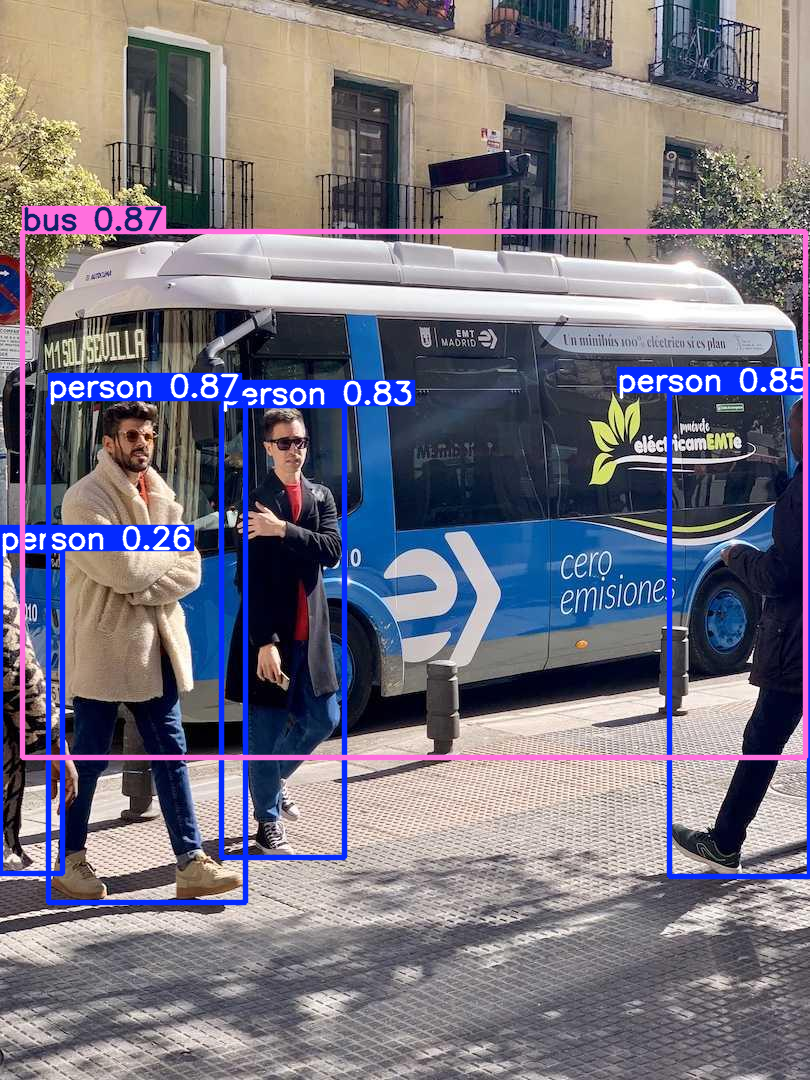

tensor([[2.2866e+01, 2.3135e+02, 8.0517e+02, 7.5778e+02, 8.7158e-01, 5.0000e+00],
        [4.8611e+01, 3.9868e+02, 2.4553e+02, 9.0260e+02, 8.6560e-01, 0.0000e+00],
        [6.6950e+02, 3.9258e+02, 8.0972e+02, 8.7660e+02, 8.5265e-01, 0.0000e+00],
        [2.2143e+02, 4.0579e+02, 3.4499e+02, 8.5790e+02, 8.2501e-01, 0.0000e+00],
        [0.0000e+00, 5.5037e+02, 6.2943e+01, 8.7367e+02, 2.6224e-01, 0.0000e+00]], device='cuda:0')


In [ ]:
import requests
from PIL import Image
import io

# Download a sample image
image_url = 'https://ultralytics.com/images/bus.jpg'
response = requests.get(image_url)
image = Image.open(io.BytesIO(response.content))
image.save('bus.jpg')

print(f"Downloaded sample image from {image_url}")

# Perform object detection on the image
results = model('bus.jpg')

# Display the results (this will show the image with bounding boxes)
results[0].show()

# Optionally, print the detection details
for r in results:
    print(r.boxes.data)